(np.float64(-0.5), np.float64(309.5), np.float64(91.5), np.float64(-0.5))

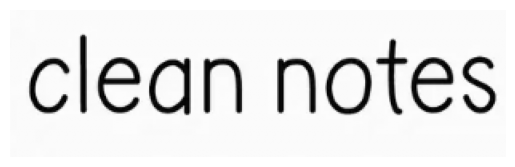

In [1]:
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread('image.png')

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.axis(False)

Apply blur to image to minimize the noise

(np.float64(-0.5), np.float64(309.5), np.float64(91.5), np.float64(-0.5))

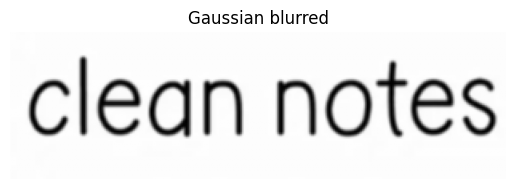

In [2]:
blurred = cv.GaussianBlur(gray, (3, 3), 0)
plt.imshow(blurred, cmap='gray')
plt.title('Gaussian blurred')
plt.axis('off')

Use adaptive threshold to convert grayscale to pure black and white

(np.float64(-0.5), np.float64(309.5), np.float64(91.5), np.float64(-0.5))

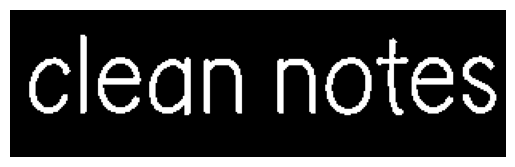

In [3]:
thresh = cv.adaptiveThreshold(
    blurred, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY_INV, 15, 8
)
plt.imshow(thresh, cmap='gray')
plt.axis('off')

Dilate to merge nearby strokes

(np.float64(-0.5), np.float64(309.5), np.float64(91.5), np.float64(-0.5))

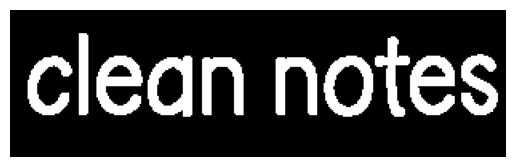

In [4]:
kernel = cv.getStructuringElement(cv.MORPH_RECT, (3, 3))
dilated = cv.dilate(thresh, kernel, iterations=1)

plt.imshow(dilated, cmap='gray')
plt.axis('off')

Find contours

In [5]:
contours, hierarchy = cv.findContours(dilated, cv.RETR_CCOMP, cv.CHAIN_APPROX_SIMPLE)
print(f"Total contours found = {len(contours)}")

Total contours found = 14


filter out the contours

In [6]:
image_area = gray.shape[0] * gray.shape[1]
min_area = image_area * 0.001   #atleast 0.1% of image
max_area = image_area * 0.95    #atmost 95% of image

filtered_contours = []

for i, contour in enumerate(contours):
    area = cv.contourArea(contour)
    if hierarchy[0][i][3] == -1:
        has_no_parent = True
    else:
        has_no_parent = False

    if has_no_parent and min_area < area < max_area:
        filtered_contours.append(contour)

filtered_contours = sorted(filtered_contours, key = lambda x: cv.boundingRect(x)[0])
print(f"Valid symbols = {len(filtered_contours)}")

Valid symbols = 10


(np.float64(-0.5), np.float64(309.5), np.float64(91.5), np.float64(-0.5))

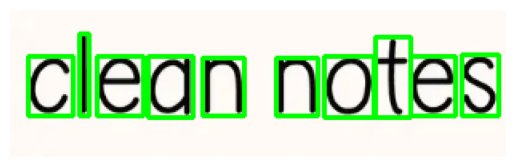

In [7]:
display = cv.cvtColor(img.copy(), cv.COLOR_BGR2RGB)
for contour in filtered_contours:
    x, y, w, h = cv.boundingRect(contour)
    cv.rectangle(display, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.imshow(display)
plt.axis('off')

Crop each detected symbol from thresh resize it to 28 x 28 and adding some padding to match EMNIST dataset format.

In [8]:
crops = []
SYMBOL_SIZE = 28
PADDING = 4
for contour in filtered_contours:
    x, y, w, h = cv.boundingRect(contour)

    #Add paddings
    x1 = max(0, x - PADDING)
    y1 = max(0, y - PADDING)
    x2 = min(thresh.shape[1], x + w + PADDING)
    y2 = min(thresh.shape[0], y + h + PADDING)

    crop = thresh[y1:y2, x1:x2]
    crop_resized = cv.resize(crop, (SYMBOL_SIZE, SYMBOL_SIZE))
    crops.append(crop_resized)

Save the crops

In [9]:
import os

os.makedirs('symbols', exist_ok=True)
for i, crop in enumerate(crops):
    cv.imwrite(f'symbols/symbol_{i+1}.png', crop)